## EEG Data From Parkinsons Disease Patient Dataset

In a healthy brain, beta oscillations (13–30 Hz) in the motor cortex typically decrease in synchronization immediately before and during voluntary movement. This process, known as beta desynchronization, allows motor networks to transition from maintaining the current motor state to executing new movements.

In Parkinson's disease (PD), dopamine deficiency within the basal ganglia-thalamo-cortical network produces pathological beta hypersynchrony. This excessive synchronization is strongly correlated with bradykinesia and rigidity, making the beta band a primary electrophysiological target for analyzing Parkinsonian motor dysfunction.

Abnormal beta activity does not occur in isolation. Swann et al. (Elevated Synchrony in Parkinson's Disease Detected with Electroencephalography) demonstrated that Parkinson's patients exhibit pathological Phase-Amplitude Coupling (PAC)—a phenomenon where the phase of slower beta oscillations modulates the amplitude of faster gamma activity. This coupling serves as a non-invasive biomarker of the Parkinsonian state, distinct from raw spectral power.

#### **Research Objectives & Feature Space**

To quantify these neuro-pathologies, this project investigates three primary frequency bands within the sensorimotor cortex (channels C3 and C4):
- **Theta (4–6 Hz)**: Targeted to identify neural slowing and tremor-related dynamics.
- **Beta (13–30 Hz)**: Targeted to measure hypersynchrony and inter-hemispheric functional connectivity.
- **Broadband Gamma (30–50 Hz)**: Targeted to assess PAC; this range was specifically selected to avoid 60 Hz power-line interference.

#### **Methodological Approach**

We utilize a within-subject design, comparing medicated (ON) and unmedicated (OFF) states to control for anatomical baseline variance. Our analysis focuses on two core metrics of network dynamics:
1) **Inter-hemispheric Phase-Locking Value (PLV)**: By computing the Hilbert-transformed phase difference between C3 and C4, we quantify the consistency of functional connectivity between the left and right sensorimotor cortices.
2) **Phase-Amplitude Coupling (PAC)**: We calculate the Modulation Index: A non-linear metric quantifying how beta-phase ($\phi_\beta$) dictates the amplitude envelope of gamma-bursts ($A_\gamma$).

This multi-dimensional feature space; comprising spectral power, inter-hemispheric synchrony, and cross-frequency coupling, serves as the input for our predictive classification pipeline.


In [29]:
import mne
from mne_bids import BIDSPath, read_raw_bids
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert

# Define routing variables
bids_root = "../data/raw" 
subject_id = "pd6"
task = "rest"


#### Construct the strict BIDS paths


In [16]:
path_off = BIDSPath(subject=subject_id, session='off', task=task, datatype='eeg', root=bids_root)
path_on = BIDSPath(subject=subject_id, session='on', task=task, datatype='eeg', root=bids_root)

##### Load Data into memory

In [17]:
print(f"Loading Unmedicated (OFF) State...")
raw_off = read_raw_bids(bids_path=path_off, verbose=False)
raw_off.load_data()

print(f"Loading Medicated (ON) State...")
raw_on = read_raw_bids(bids_path=path_on, verbose=False)
raw_on.load_data()

Loading Unmedicated (OFF) State...
Reading 0 ... 97791  =      0.000 ...   190.998 secs...
Loading Medicated (ON) State...
Reading 0 ... 147967  =      0.000 ...   288.998 secs...


/var/folders/rn/tq3n69nx16783lcjv4tgtf5c0000gn/T/ipykernel_32078/3733840632.py:2: RuntimeWarning: Unable to map the following column(s) to to MNE:
gender: f
MMSE: 30
NAART: 42
disease_duration: 8
rl_deficits: L OFF meds, more R ON meds
notes: Used preprocessed data from EEGLAB .mat file instead of raw data for pd on
  raw_off = read_raw_bids(bids_path=path_off, verbose=False)
/var/folders/rn/tq3n69nx16783lcjv4tgtf5c0000gn/T/ipykernel_32078/3733840632.py:6: RuntimeWarning: Unable to map the following column(s) to to MNE:
gender: f
MMSE: 30
NAART: 42
disease_duration: 8
rl_deficits: L OFF meds, more R ON meds
notes: Used preprocessed data from EEGLAB .mat file instead of raw data for pd on
  raw_on = read_raw_bids(bids_path=path_on, verbose=False)


<RawBDF | sub-pd6_ses-on_task-rest_eeg.bdf, 41 x 147968 (289.0 s), ~46.3 MiB, data loaded>

##### Standardize the montage so we can find C3 and C4

In [18]:
montage = mne.channels.make_standard_montage('standard_1020')
raw_off.set_montage(montage, match_case=False, match_alias=True, on_missing='ignore')
raw_on.set_montage(montage, match_case=False, match_alias=True, on_missing='ignore')

<RawBDF | sub-pd6_ses-on_task-rest_eeg.bdf, 41 x 147968 (289.0 s), ~46.3 MiB, data loaded>

##### Extract just a 2-second snippet of C3 and C4 for visualization.

In [22]:
viz_off = raw_off.copy().pick(['C3', 'C4']).filter(l_freq=1.0, h_freq=50.0, verbose=False)
viz_on = raw_on.copy().pick(['C3', 'C4']).filter(l_freq=1.0, h_freq=50.0, verbose=False)


#### Plot the side-by-side comparison

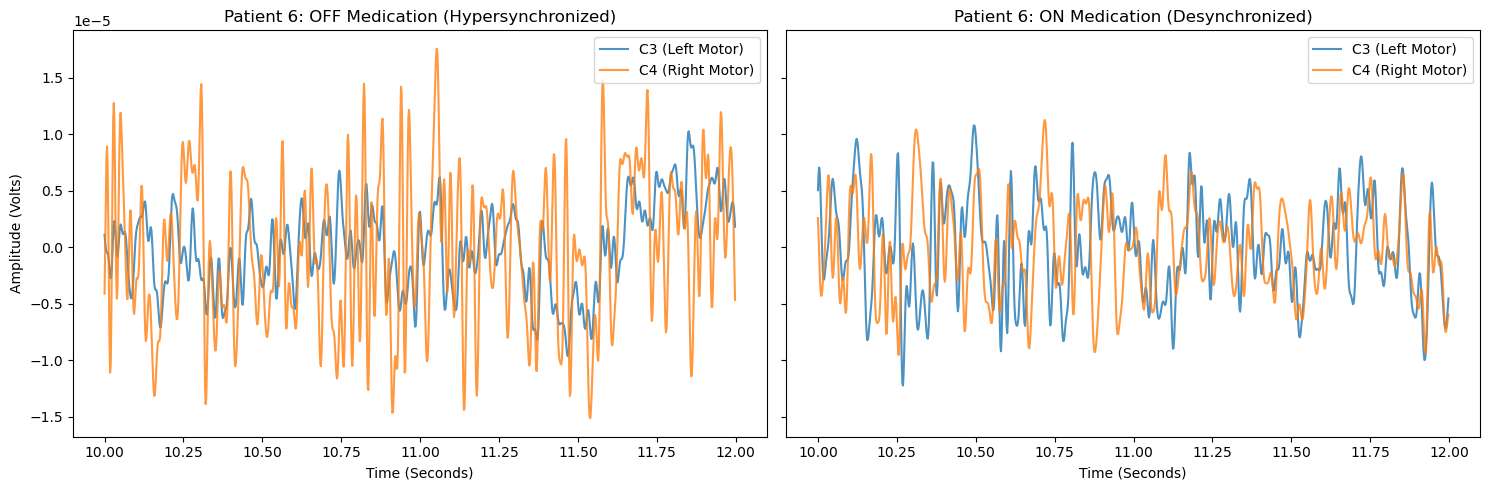

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Extract just a 2-second snippet of C3 and C4
# We filter it slightly just so the plot is readable
viz_off = raw_off.copy().pick(['C3', 'C4']).filter(l_freq=1.0, h_freq=50.0, verbose=False)
viz_on = raw_on.copy().pick(['C3', 'C4']).filter(l_freq=1.0, h_freq=50.0, verbose=False)

# Convert from continuous data to a 2-second numpy array (10s to 12s)
sfreq = raw_off.info['sfreq']
start_samp = int(10.0 * sfreq)
stop_samp = int(12.0 * sfreq)

data_off, times = viz_off.get_data(start=start_samp, stop=stop_samp, return_times=True)
data_on, _ = viz_on.get_data(start=start_samp, stop=stop_samp, return_times=True)

# Plot the side-by-side comparison using Matplotlib
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Plot OFF state (Overlaid to see phase alignment)
axes[0].plot(times, data_off[0], label='C3 (Left Motor)', alpha=0.8)
axes[0].plot(times, data_off[1], label='C4 (Right Motor)', alpha=0.8)
axes[0].set_title("Patient 6: OFF Medication (Hypersynchronized)")
axes[0].set_xlabel("Time (Seconds)")
axes[0].set_ylabel("Amplitude (Volts)")
axes[0].legend(loc='upper right')

# Plot ON state
axes[1].plot(times, data_on[0], label='C3 (Left Motor)', alpha=0.8)
axes[1].plot(times, data_on[1], label='C4 (Right Motor)', alpha=0.8)
axes[1].set_title("Patient 6: ON Medication (Desynchronized)")
axes[1].set_xlabel("Time (Seconds)")
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

As visualized above, the raw time-series data provides compelling evidence of our clinical hypothesis. In the unmedicated state, the C3 and C4 motor cortex channels exhibit visible phase alignment (pathological hypersynchrony). Conversely, the introduction of Levodopa (ON state) actively disrupts this coupling, allowing the hemispheres to operate more independently.

However, visual inspection alone is insufficient. To build a robust predictive model, we must translate these observations into quantifiable, machine-readable features. We will apply advanced signal processing techniques to extract three distinct classes of non-linear biomarkers:

1. **Spectral Power (Log Variance):** Quantifying the absolute energy of Theta (4–6 Hz) and Beta (13–30 Hz) oscillations to capture frequency-specific slowing and hypersynchrony.
2. **Inter-hemispheric Phase-Locking Value (PLV):** Utilizing the Hilbert transform to extract the instantaneous phase of the signals, allowing us to quantify the synchronization consistency between the left (C3) and right (C4) motor cortices.
3. **Phase-Amplitude Coupling (PAC):** Measuring how the phase of the slow Beta rhythm modulates the amplitude of the fast Gamma (30–50 Hz) rhythm, capturing the complex, cross-frequency interactions identified by Swann et al.

#### Epoching and Log variance

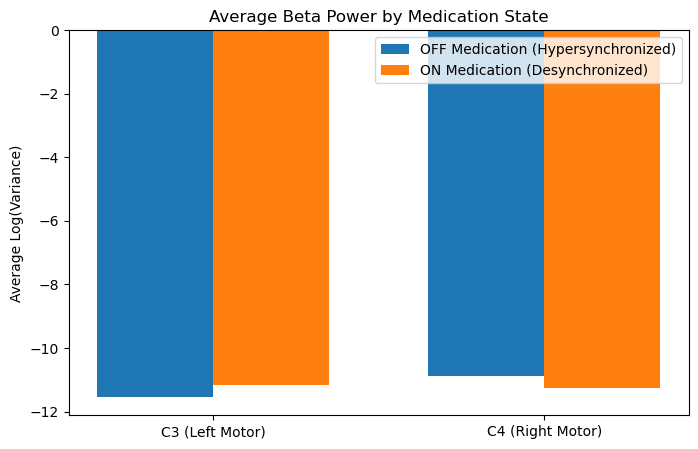

In [31]:
# Create fixed length epochs (2-second) for both states
epochs_off = mne.make_fixed_length_epochs(raw_off, duration=2.0, overlap=0.0, preload=True, verbose=False).pick(['C3', 'C4'])
epochs_on = mne.make_fixed_length_epochs(raw_on, duration=2.0, overlap=0.0, preload=True, verbose=False).pick(['C3', 'C4'])

# 2. Filter into our specific predictive bands
bands = {
    'Theta': (4.0, 6.0),
    'Beta': (13.0, 30.0),
    'Gamma': (30.0, 50.0)
}

# Extract numpy arrays of shape (n_epochs, n_channels, n_times)
filt_off = {name: epochs_off.copy().filter(fmin, fmax, verbose=False).get_data() for name, (fmin, fmax) in bands.items()}
filt_on = {name: epochs_on.copy().filter(fmin, fmax, verbose=False).get_data() for name, (fmin, fmax) in bands.items()}

# Calculate Log Variance (Power) for Beta band
beta_pow_off = np.mean(np.log10(np.var(filt_off['Beta'], axis=2)), axis=0)
beta_pow_on = np.mean(np.log10(np.var(filt_on['Beta'], axis=2)), axis=0)

# Power difference plot
labels = ['C3 (Left Motor)', 'C4 (Right Motor)']
x = np.arange(len(labels))
width = 0.35

plt.close('all')
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, beta_pow_off, width, label='OFF Medication (Hypersynchronized)')
ax.bar(x + width/2, beta_pow_on, width, label='ON Medication (Desynchronized)')
ax.set_ylabel('Average Log(Variance)')
ax.set_title('Average Beta Power by Medication State')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')
plt.show()

### Phase-Locking Value

To quantify inter-hemispheric synchronization, we calculate the Phase-Locking Value (PLV) between C3 and C4. PLV is calculated as $PLV = \left| \frac{1}{N} \sum e^{i(\phi_1 - \phi_2)} \right|$

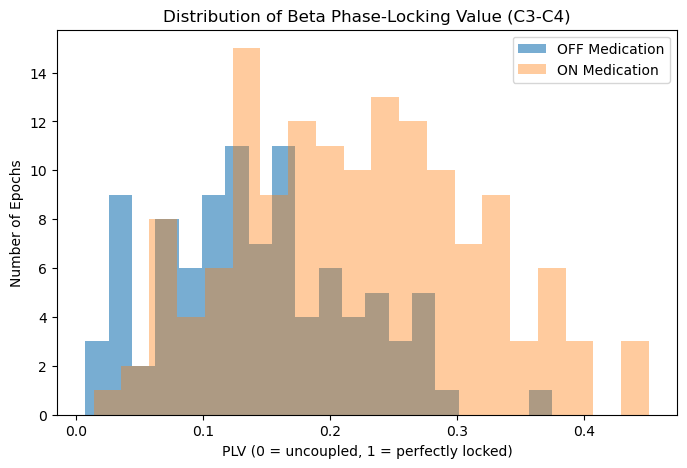

In [36]:
def calculate_plv(beta_data):
    plvs = []
    for epoch in beta_data:
        phase_c3 = np.angle(hilbert(epoch[0]))
        phase_c4 = np.angle(hilbert(epoch[1]))
        plv = np.abs(np.mean(np.exp(1j * (phase_c3 - phase_c4))))
        plvs.append(plv)
    return plvs

plv_off = calculate_plv(filt_off['Beta'])
plv_on = calculate_plv(filt_on['Beta'])

plt.close('all')
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(plv_off, alpha=0.6, bins=20, label='OFF Medication')
ax.hist(plv_on, alpha=0.4, bins=20, label='ON Medication')
ax.set_title('Distribution of Beta Phase-Locking Value (C3-C4)')
ax.set_xlabel('PLV (0 = uncoupled, 1 = perfectly locked)')
ax.set_ylabel('Number of Epochs')
ax.legend()
plt.show()

**Observation: Biological Variance in Phase Locking**

Interestingly, the distribution above reveals that for this specific patient, inter-hemispheric phase locking (PLV) actually *increased* while on medication. While this doesnt agree with the average statistical trend found in broader studies, it highlights the danger of relying on a single biomarker for this kind of classification. Human neurophysiology contains individual variance—factors like electrode placement, skull anatomy, and specific disease sub-types can invert expected trends. 

To accurately classify this state, our model cannot rely on phase alignment alone. We must look deeper into the non-linear network dynamics, specifically examining how this beta rhythm interacts with other frequencies via Phase-Amplitude Coupling (PAC).

### Phase-Amplitude Coupling (PAC)

To measure cross-frequency coupling, we calculate the Modulation Index, which quantifies how the phase of the slower Beta rhythm ($\phi_\beta$) dictates the amplitude envelope of the faster Gamma rhythm ($A_\gamma$). The equation is defined as $PAC = \log_{10} \left| \frac{1}{N} \sum A_\gamma e^{i \phi_\beta} \right|$.

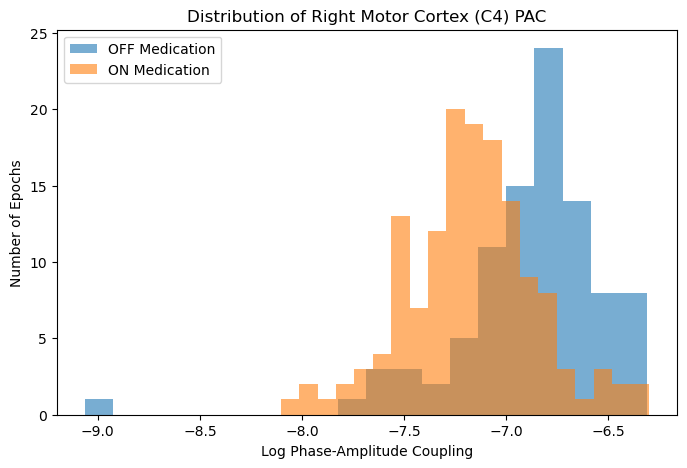

In [35]:
def calculate_pac(beta_data, gamma_data):
    pac_c4 = []
    for i in range(len(beta_data)):
        phase_b_c4 = np.angle(hilbert(beta_data[i][1]))
        amp_g_c4 = np.abs(hilbert(gamma_data[i][1]))
        
        # Log transformed Modulation Index
        pac_value = np.log10(np.abs(np.mean(amp_g_c4 * np.exp(1j * phase_b_c4))))
        pac_c4.append(pac_value)
    return pac_c4

pac_off = calculate_pac(filt_off['Beta'], filt_off['Gamma'])
pac_on = calculate_pac(filt_on['Beta'], filt_on['Gamma'])

plt.close('all')
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pac_off, alpha=0.6, bins=20, label='OFF Medication')
ax.hist(pac_on, alpha=0.6, bins=20, label='ON Medication')
ax.set_title('Distribution of Right Motor Cortex (C4) PAC')
ax.set_xlabel('Log Phase-Amplitude Coupling')
ax.set_ylabel('Number of Epochs')
ax.legend()
plt.show()

**Observation: Pathological Cross-Frequency Coupling**

Unlike the PLV response, the Phase-Amplitude Coupling (PAC) metric performs exactly as predicted by the physiological literature (Swann et al.). In the unmedicated state (blue), the distribution is heavily shifted to the right, indicating strong pathological coupling where the phase of the hypersynchronized beta rhythm dictates the amplitude of high-frequency gamma bursts. 

Upon the introduction of Levodopa (orange), this distribution shifts to the left. The medication successfully breaks the cross-frequency lock. This visualization illustrates the necessity of a Machine Learning approach: even when raw phase alignment (PLV) fails to decouple due to patient-specific biological variance, the non-linear network dynamics (PAC) capture the true neurological state shift